# TASK 1 — EXPLORATORY DATA ANALYSIS (EDA)

## Dataset Overview

This notebook performs EDA on the two 2025 synthetic datasets:
- `consumer_financial_health_engagement_2025`: consumer-month grain.
- `consumer_transactions_2025`: transaction-level grain.

The analysis is organized into seven stages: Data Loading & Overview, Missing Values, Data Consistency, Data Integrity / Logical Consistency, Descriptive Statistics, Distribution / Outlier Check, and the five Task 1 business questions.

---
## 1. Data Loading & Overview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_monthly = pd.read_csv('../data/consumer_financial_health_engagement_2025.csv')
df_txn = pd.read_csv('../data/consumer_transactions_2025.csv')

df_monthly['analysis_month'] = pd.to_datetime(df_monthly['analysis_month'])
df_txn['activity_datetime'] = pd.to_datetime(df_txn['activity_datetime'])

print('Monthly dataset shape:', df_monthly.shape)
print('Transaction dataset shape:', df_txn.shape)

Monthly dataset shape: (10992, 30)
Transaction dataset shape: (1852394, 28)


### 1.1 Shape, columns, data types, and head

In [2]:
print('--- MONTHLY DATASET ---')
print(df_monthly.info())
display(df_monthly.head())

print('\n--- TRANSACTION DATASET ---')
print(df_txn.info())
display(df_txn.head())

--- MONTHLY DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 0 to 10991
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   consumer_id                    10992 non-null  object        
 1   analysis_month                 10992 non-null  datetime64[ns]
 2   age                            10992 non-null  int64         
 3   gender                         10992 non-null  object        
 4   occupation                     10992 non-null  object        
 5   province_city                  10992 non-null  object        
 6   monthly_income_vnd             10992 non-null  int64         
 7   credit_limit_vnd               10992 non-null  int64         
 8   opening_balance_vnd            10992 non-null  int64         
 9   ending_balance_vnd             10992 non-null  int64         
 10  total_spend_vnd                10992 non-null  int64      

,consumer_id,analysis_month,age,gender,occupation,province_city,monthly_income_vnd,credit_limit_vnd,opening_balance_vnd,ending_balance_vnd,...,online_spend_ratio,spend_to_income_ratio,credit_utilization_ratio,transaction_recency_days,spending_volatility,engagement_score,financial_health_score,engagement_segment,financial_health_segment,next_month_low_health_flag
0,KH00100010,2025-01-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,1003930000,3780600000,501965000,1065133000,...,0.156763,0.4390,0.1166,0,0.978194,77.4,74.4,Tương tác cao,Ổn định,0.0
1,KH00100010,2025-02-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,961510000,3780600000,1065133000,1627173000,...,0.147195,0.4155,0.1057,0,0.891546,77.1,76.3,Tương tác cao,Ổn định,0.0
2,KH00100010,2025-03-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,916740000,3780600000,1627173000,2029964000,...,0.186583,0.5606,0.1359,0,0.972394,79.0,71.2,Tương tác cao,Ổn định,0.0
3,KH00100010,2025-04-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,882330000,3780600000,2029964000,2323507000,...,0.159083,0.6673,0.1557,0,0.880536,78.0,69.0,Tương tác cao,Ổn định,0.0
4,KH00100010,2025-05-01,27,Nam,Kỹ sư sản xuất,Đồng Nai,1053200000,3780600000,2323507000,2912082000,...,0.157146,0.4412,0.1229,0,0.848012,77.9,75.8,Tương tác cao,Ổn định,0.0



--- TRANSACTION DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 28 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   transaction_id           object        
 1   activity_datetime        datetime64[ns]
 2   consumer_id              object        
 3   customer_name            object        
 4   gender                   object        
 5   date_of_birth            object        
 6   age_at_transaction       int64         
 7   occupation               object        
 8   street_address           object        
 9   ward_commune             object        
 10  province_city            object        
 11  administrative_code      int64         
 12  customer_latitude        float64       
 13  customer_longitude       float64       
 14  local_population         int64         
 15  merchant_id              object        
 16  merchant_name            object        
 17

,transaction_id,activity_datetime,consumer_id,customer_name,gender,date_of_birth,age_at_transaction,occupation,street_address,ward_commune,...,spend_amount_vnd,merchant_latitude,merchant_longitude,transaction_channel,payment_method,online_transaction_flag,essential_spending_flag,transaction_month,transaction_day_of_week,transaction_hour
0,GD20250000000001,2025-01-01 00:00:18,KH00102405,Lý Ngọc Nga,Nữ,1993-03-09,31,Nhà tâm lý học tư vấn,Số 372 đường Lê Lai,Tân Lập,...,124000,13.988415,107.991722,E-commerce,Ví điện tử,1,0,1,2,0
1,GD20250000000002,2025-01-01 00:00:44,KH00118490,Trịnh Minh Lan,Nữ,1983-06-21,41,Giáo viên giáo dục đặc biệt,Số 289 đường Phạm Ngũ Lão,Bắc Sơn,...,2681000,20.875701,106.647480,POS,Thẻ tín dụng,0,1,1,2,0
2,GD20250000000003,2025-01-01 00:00:51,KH00109845,Đào Anh Vũ,Nam,1967-01-19,57,Cán bộ bảo tồn thiên nhiên,Số 36 đường Phan Đình Phùng,Gò Vấp,...,5503000,10.803963,106.633380,POS,Thẻ ghi nợ,0,0,1,2,0
3,GD20250000000004,2025-01-01 00:00:57,KH00101970,Trịnh Kim Mai,Nữ,1955-05-27,69,Chuyên viên tư vấn nông nghiệp,Số 82 đường Nguyễn Văn Cừ,Chiềng Sinh,...,228000,21.211890,106.046038,E-commerce,Ví điện tử,1,0,1,2,0
4,GD20250000000005,2025-01-01 00:01:16,KH00105725,Trần Ngọc Phong,Nam,1972-01-12,52,Luật sư sáng chế,Số 42 đường Lê Lợi,Vinh Tân,...,1125000,20.979769,107.111416,QR Payment,QR,0,1,1,2,0


### 1.2 Grain and key fields

- Monthly dataset: one row per `consumer_id` × `analysis_month`.
- Transaction dataset: one row per `transaction_id`.
- `consumer_id` is the linking key between the two datasets.
- Monthly-only indicators such as financial health, engagement, ratios, income, credit limit, and balances must be analyzed at the consumer-month grain.

In [3]:
print('Unique consumers - monthly:', df_monthly['consumer_id'].nunique())
print('Unique consumers - transactions:', df_txn['consumer_id'].nunique())
print('Unique transaction IDs:', df_txn['transaction_id'].nunique())
print('Monthly date range:', df_monthly['analysis_month'].min(), 'to', df_monthly['analysis_month'].max())
print('Transaction date range:', df_txn['activity_datetime'].min(), 'to', df_txn['activity_datetime'].max())

Unique consumers - monthly: 999
Unique consumers - transactions: 999
Unique transaction IDs: 1852394
Monthly date range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Transaction date range: 2025-01-01 00:00:18 to 2025-12-31 23:59:53


---
## 2. Missing Values

In [4]:
def missing_summary(df):
    out = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100
    })
    return out[out['missing_count'] > 0].sort_values('missing_count', ascending=False)

print('Monthly missing values:')
display(missing_summary(df_monthly))

print('Transaction missing values:')
display(missing_summary(df_txn))

Monthly missing values:


,missing_count,missing_pct
next_month_low_health_flag,999,9.088428


Transaction missing values:


,missing_count,missing_pct


### 2.1 Missing pattern

Inspect whether missing values are concentrated in particular months, consumers, or fields. For the monthly dataset, `next_month_low_health_flag` is expected to be unavailable for the final month because there is no subsequent month in the 2025 observation window.

In [5]:
if 'next_month_low_health_flag' in df_monthly.columns:
    print('Missing next_month_low_health_flag by month:')
    display(df_monthly.groupby('analysis_month')['next_month_low_health_flag'].apply(lambda s: s.isna().sum()).to_frame('missing_count'))

print('Duplicate rows - monthly:', df_monthly.duplicated().sum())
print('Duplicate rows - transactions:', df_txn.duplicated().sum())

Missing next_month_low_health_flag by month:


,missing_count
analysis_month,
2025-01-01,7
2025-02-01,11
2025-03-01,12
2025-04-01,10
2025-05-01,9
2025-06-01,3
2025-07-01,5
2025-08-01,3
2025-09-01,10


Duplicate rows - monthly: 0
Duplicate rows - transactions: 0


**Comment:** 

Missing values are found only in ``next_month_low_health_flag`` in the monthly dataset, while the transaction dataset contains no missing values. Most missing target values occur in December, which is expected because the following month is outside the 2025 observation window. However, a small number of missing values also appear in earlier months, so these cases should be investigated separately rather than assuming that all missing values are expected.

---
## 3. Data Consistency

### 3.1 Primary Key Check

Check whether the expected primary keys are unique:
- Monthly dataset: `consumer_id` + `analysis_month`
- Transaction dataset: `transaction_id`

In [30]:
monthly_key_dup = df_monthly.duplicated(
    subset=['consumer_id', 'analysis_month']
).sum()

txn_key_dup = df_txn['transaction_id'].duplicated().sum()

print(
    'Duplicate consumer_id + analysis_month:',
    monthly_key_dup
)

print(
    'Duplicate transaction_id:',
    txn_key_dup
)

Duplicate consumer_id + analysis_month: 0
Duplicate transaction_id: 0


**Comment:** No duplicate primary keys were found in either dataset. This indicates that each consumer-month record and each transaction record is uniquely identified.

### 3.2 Linking Key Check

Check whether `consumer_id` is consistent across the monthly and transaction datasets.

In [31]:
monthly_consumers = set(
    df_monthly['consumer_id'].dropna().unique()
)

txn_consumers = set(
    df_txn['consumer_id'].dropna().unique()
)

orphan_txn_consumers = txn_consumers - monthly_consumers
monthly_without_txn = monthly_consumers - txn_consumers

print(
    'Transaction consumers not found in monthly dataset:',
    len(orphan_txn_consumers)
)

print(
    'Monthly consumers without transactions:',
    len(monthly_without_txn)
)

Transaction consumers not found in monthly dataset: 0
Monthly consumers without transactions: 0


**Comment:** All consumers in the transaction dataset are also present in the monthly dataset, and there are no monthly consumers without transaction records. Therefore, consumer_id provides complete coverage for linking the two datasets.

### 3.3 Duplicate & NULL Key Check

Check for completely duplicated records and missing values in key and date fields.

In [37]:
# Check for completely duplicated rows

print(
    'Duplicate full rows - monthly:',
    df_monthly.duplicated().sum()
)

print(
    'Duplicate full rows - transactions:',
    df_txn.duplicated().sum()
)

print('\n--- NULL CHECK ---')

# Check NULL values in key and date fields

print(
    'NULL consumer_id - monthly:',
    df_monthly['consumer_id'].isna().sum()
)

print(
    'NULL consumer_id - transactions:',
    df_txn['consumer_id'].isna().sum()
)

print(
    'NULL transaction_id:',
    df_txn['transaction_id'].isna().sum()
)

print(
    'NULL analysis_month:',
    df_monthly['analysis_month'].isna().sum()
)

print(
    'NULL activity_datetime:',
    df_txn['activity_datetime'].isna().sum()
)

Duplicate full rows - monthly: 0
Duplicate full rows - transactions: 0

--- NULL CHECK ---
NULL consumer_id - monthly: 0
NULL consumer_id - transactions: 0
NULL transaction_id: 0
NULL analysis_month: 0
NULL activity_datetime: 0


**Comment:** No completely duplicated rows or NULL values were found in the key and date fields. This indicates that the records are complete enough for identification, linking, and time-based analysis.

### 3.4 Value & Range Check

Check whether financial, score, ratio, and binary variables fall within their expected ranges.

In [38]:
# ------------------------------------------------------------
# Negative value check
# ------------------------------------------------------------

print('--- NEGATIVE VALUE CHECK ---')

monthly_non_negative_cols = [
    'monthly_income_vnd',
    'credit_limit_vnd',
    'opening_balance_vnd',
    'ending_balance_vnd',
    'total_spend_vnd',
    'essential_spend_vnd',
    'discretionary_spend_vnd',
    'online_spend_vnd',
    'transaction_count',
    'active_transaction_days',
    'average_transaction_value_vnd',
    'category_diversity',
    'transaction_recency_days'
]

for col in monthly_non_negative_cols:
    print(
        f'{col}:',
        (df_monthly[col] < 0).sum(),
        'negative values'
    )

print(
    'spend_amount_vnd:',
    (df_txn['spend_amount_vnd'] < 0).sum(),
    'negative values'
)


# ------------------------------------------------------------
# Score range check
# ------------------------------------------------------------

print('\n--- SCORE RANGE CHECK ---')

score_cols = [
    'engagement_score',
    'financial_health_score'
]

for col in score_cols:

    invalid = ~df_monthly[col].between(0, 100)

    print(
        f'{col}:',
        invalid.sum(),
        'values outside [0, 100]'
    )


# ------------------------------------------------------------
# Ratio range check
# ------------------------------------------------------------

print('\n--- RATIO RANGE CHECK ---')

ratio_cols = [
    'essential_spend_ratio',
    'discretionary_spend_ratio',
    'online_spend_ratio',
    'credit_utilization_ratio'
]

for col in ratio_cols:

    invalid = ~df_monthly[col].between(0, 1)

    print(
        f'{col}:',
        invalid.sum(),
        'values outside [0, 1]'
    )

# spend_to_income_ratio can exceed 1 when
# spending is higher than monthly income.
print(
    'spend_to_income_ratio:',
    (df_monthly['spend_to_income_ratio'] < 0).sum(),
    'negative values'
)


# ------------------------------------------------------------
# Binary flag check
# ------------------------------------------------------------

print('\n--- BINARY FLAG CHECK ---')

binary_cols = [
    'online_transaction_flag',
    'essential_spending_flag'
]

for col in binary_cols:

    invalid = ~df_txn[col].isin([0, 1])

    print(
        f'{col}:',
        invalid.sum(),
        'invalid values'
    )

--- NEGATIVE VALUE CHECK ---
monthly_income_vnd: 0 negative values
credit_limit_vnd: 0 negative values
opening_balance_vnd: 0 negative values
ending_balance_vnd: 0 negative values
total_spend_vnd: 0 negative values
essential_spend_vnd: 0 negative values
discretionary_spend_vnd: 0 negative values
online_spend_vnd: 0 negative values
transaction_count: 0 negative values
active_transaction_days: 0 negative values
average_transaction_value_vnd: 0 negative values
category_diversity: 0 negative values
transaction_recency_days: 0 negative values
spend_amount_vnd: 0 negative values

--- SCORE RANGE CHECK ---
engagement_score: 0 values outside [0, 100]
financial_health_score: 0 values outside [0, 100]

--- RATIO RANGE CHECK ---
essential_spend_ratio: 0 values outside [0, 1]
discretionary_spend_ratio: 0 values outside [0, 1]
online_spend_ratio: 0 values outside [0, 1]
credit_utilization_ratio: 5 values outside [0, 1]
spend_to_income_ratio: 0 negative values

--- BINARY FLAG CHECK ---
online_trans

**Comment:** No negative values, invalid score values, or invalid binary flags were detected. Most ratio variables are also within their expected [0, 1] range. However, five `credit_utilization_ratio` values are above 1 and should be investigated further. The `spend_to_income_ratio` is only checked for negative values because a value above 1 can occur when monthly spending exceeds monthly income.

### 3.5 Date & Field Consistency Check

Check whether dates fall within the 2025 observation period and whether `transaction_month` is consistent with `activity_datetime`.

In [39]:
# ------------------------------------------------------------
# Date range check
# ------------------------------------------------------------

print('--- DATE RANGE CHECK ---')

monthly_invalid_2025 = (
    ~df_monthly['analysis_month'].dt.year.eq(2025)
)

txn_invalid_2025 = (
    ~df_txn['activity_datetime'].dt.year.eq(2025)
)

print(
    'Monthly records outside year 2025:',
    monthly_invalid_2025.sum()
)

print(
    'Transaction records outside year 2025:',
    txn_invalid_2025.sum()
)

print(
    'Monthly date range:',
    df_monthly['analysis_month'].min(),
    'to',
    df_monthly['analysis_month'].max()
)

print(
    'Transaction date range:',
    df_txn['activity_datetime'].min(),
    'to',
    df_txn['activity_datetime'].max()
)


# ------------------------------------------------------------
# Transaction month consistency
# ------------------------------------------------------------

print('\n--- TRANSACTION MONTH CONSISTENCY ---')

calculated_month = df_txn['activity_datetime'].dt.month

month_mismatch = (
    df_txn['transaction_month'] != calculated_month
)

print(
    'transaction_month mismatches activity_datetime:',
    month_mismatch.sum()
)

--- DATE RANGE CHECK ---
Monthly records outside year 2025: 0
Transaction records outside year 2025: 0
Monthly date range: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Transaction date range: 2025-01-01 00:00:18 to 2025-12-31 23:59:53

--- TRANSACTION MONTH CONSISTENCY ---
transaction_month mismatches activity_datetime: 0


**Comment:** All monthly and transaction records fall within the 2025 observation period. In addition, `transaction_month` is consistent with the month extracted from `activity_datetime`, with no mismatched records detected.

---
## 4. Data Integrity / Logical Consistency

### 4.1 Monthly spend components

Check whether `essential_spend_vnd + discretionary_spend_vnd` reconciles to `total_spend_vnd`.

In [8]:
df_monthly['spend_component_sum'] = df_monthly['essential_spend_vnd'] + df_monthly['discretionary_spend_vnd']
df_monthly['spend_component_diff'] = df_monthly['total_spend_vnd'] - df_monthly['spend_component_sum']

print('Rows where spend components do not reconcile:', (df_monthly['spend_component_diff'] != 0).sum())
print('Maximum absolute reconciliation difference:', df_monthly['spend_component_diff'].abs().max())

Rows where spend components do not reconcile: 0
Maximum absolute reconciliation difference: 0


### 4.2 Spending ratios

Expected relationships:
- `essential_spend_ratio = essential_spend_vnd / total_spend_vnd`
- `discretionary_spend_ratio = discretionary_spend_vnd / total_spend_vnd`
- Essential + discretionary ratios should be approximately 1.
- `online_spend_ratio` should be within [0, 1].
- `spend_to_income_ratio` should be non-negative; values above 1 indicate monthly spend exceeding monthly synthetic income.

In [9]:
calc_essential_ratio = df_monthly['essential_spend_vnd'] / df_monthly['total_spend_vnd']
calc_discretionary_ratio = df_monthly['discretionary_spend_vnd'] / df_monthly['total_spend_vnd']

print('Essential ratio max absolute difference:', (df_monthly['essential_spend_ratio'] - calc_essential_ratio).abs().max())
print('Discretionary ratio max absolute difference:', (df_monthly['discretionary_spend_ratio'] - calc_discretionary_ratio).abs().max())
print('Rows where essential + discretionary ratios != 1 (tolerance 1e-6):', ((df_monthly['essential_spend_ratio'] + df_monthly['discretionary_spend_ratio'] - 1).abs() > 1e-6).sum())
print('Online ratio outside [0,1]:', (~df_monthly['online_spend_ratio'].between(0, 1)).sum())
print('Spend-to-income ratio < 0:', (df_monthly['spend_to_income_ratio'] < 0).sum())

Essential ratio max absolute difference: 1.1102230246251565e-16
Discretionary ratio max absolute difference: 1.1102230246251565e-16
Rows where essential + discretionary ratios != 1 (tolerance 1e-6): 0
Online ratio outside [0,1]: 0
Spend-to-income ratio < 0: 0


### 4.3 Balance and credit relationships

Because the financial fields are synthetic, these checks are used for internal consistency rather than realism of absolute VND amounts.

In [10]:
print('Opening balance < 0:', (df_monthly['opening_balance_vnd'] < 0).sum())
print('Ending balance < 0:', (df_monthly['ending_balance_vnd'] < 0).sum())
print('Credit limit <= 0:', (df_monthly['credit_limit_vnd'] <= 0).sum())
print('Credit utilization outside [0, 1]:', (~df_monthly['credit_utilization_ratio'].between(0, 1)).sum())

# Compare balance movement with spend as a diagnostic; do not assume a cash-flow identity
df_monthly['balance_change_vnd'] = df_monthly['ending_balance_vnd'] - df_monthly['opening_balance_vnd']
display(df_monthly[['opening_balance_vnd', 'ending_balance_vnd', 'balance_change_vnd', 'total_spend_vnd']].describe())

Opening balance < 0: 0
Ending balance < 0: 0
Credit limit <= 0: 0
Credit utilization outside [0, 1]: 5


,opening_balance_vnd,ending_balance_vnd,balance_change_vnd,total_spend_vnd
count,1.099200e+04,1.099200e+04,1.099200e+04,1.099200e+04
mean,1.258398e+09,1.413189e+09,1.547911e+08,2.951813e+08
std,1.299904e+09,1.393459e+09,1.916971e+08,2.028265e+08
min,0.000000e+00,0.000000e+00,-1.024505e+09,7.224000e+06
25%,3.948768e+08,5.037098e+08,4.659200e+07,1.470350e+08
50%,8.545280e+08,9.858515e+08,1.219475e+08,2.513860e+08
75%,1.660178e+09,1.837035e+09,2.412162e+08,3.859602e+08
max,1.437281e+10,1.516700e+10,1.470119e+09,1.866294e+09


### 4.4 Transaction-level vs monthly-level reconciliation

Aggregate transactions by `consumer_id` and month, then compare transaction count and spend against the monthly dataset. This validates that the two grains can be safely linked and clarifies which dataset should be used for each question.

In [11]:
txn_monthly = (
    df_txn.assign(analysis_month=df_txn['activity_datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby(['consumer_id', 'analysis_month'], as_index=False)
    .agg(
        txn_total_spend_vnd=('spend_amount_vnd', 'sum'),
        txn_count=('transaction_id', 'count'),
        txn_essential_spend_vnd=('spend_amount_vnd', lambda s: 0)  # placeholder; calculated below
    )
)

txn_ess = (
    df_txn.assign(analysis_month=df_txn['activity_datetime'].dt.to_period('M').dt.to_timestamp())
    .assign(essential_amount=lambda x: x['spend_amount_vnd'] * x['essential_spending_flag'])
    .groupby(['consumer_id', 'analysis_month'])['essential_amount'].sum()
    .rename('txn_essential_spend_vnd')
    .reset_index()
)

txn_monthly = txn_monthly.drop(columns='txn_essential_spend_vnd').merge(txn_ess, on=['consumer_id', 'analysis_month'], how='left')

recon = df_monthly[['consumer_id', 'analysis_month', 'total_spend_vnd', 'transaction_count', 'essential_spend_vnd']].merge(
    txn_monthly, on=['consumer_id', 'analysis_month'], how='left'
)

print('Monthly rows:', len(recon))
print('Spend reconciliation failures:', (recon['total_spend_vnd'] != recon['txn_total_spend_vnd']).sum())
print('Transaction-count reconciliation failures:', (recon['transaction_count'] != recon['txn_count']).sum())
print('Essential-spend reconciliation failures:', (recon['essential_spend_vnd'] != recon['txn_essential_spend_vnd']).sum())

Monthly rows: 10992
Spend reconciliation failures: 0
Transaction-count reconciliation failures: 0
Essential-spend reconciliation failures: 0


**Overall Comment:** The integrity checks confirm that the main financial relationships within the monthly dataset are internally consistent. Monthly spending components reconcile exactly with total spending, spending ratios follow their expected formulas, and transaction-level spending and counts reconcile with the corresponding monthly measures. However, five records have `credit_utilization_ratio` values above 1, which should be investigated further because this indicates that the reported balance exceeds the available credit limit. Overall, the datasets are suitable for further analysis, with this specific issue noted for investigation.

---
## 5. Descriptive Statistics


In [12]:
print('Monthly numerical summary:')
display(df_monthly.describe(include='number').T)

print('Transaction numerical summary:')
display(df_txn.describe(include='number').T)

categorical_monthly = ['gender', 'occupation', 'province_city', 'engagement_segment', 'financial_health_segment']
for col in categorical_monthly:
    print(f'\n--- {col} ---')
    display(df_monthly[col].value_counts(dropna=False).head(20).to_frame('count'))

Monthly numerical summary:


,count,mean,std,min,25%,50%,75%,max
age,10992.0,4.930158e+01,1.801069e+01,1.500000e+01,3.400000e+01,4.800000e+01,6.100000e+01,9.600000e+01
monthly_income_vnd,10992.0,4.498127e+08,2.875297e+08,4.547000e+07,2.253550e+08,3.970750e+08,5.950350e+08,2.086810e+09
credit_limit_vnd,10992.0,1.707068e+09,1.157493e+09,1.329000e+08,8.243000e+08,1.455500e+09,2.258300e+09,8.785800e+09
opening_balance_vnd,10992.0,1.258398e+09,1.299904e+09,0.000000e+00,3.948768e+08,8.545280e+08,1.660178e+09,1.437281e+10
ending_balance_vnd,10992.0,1.413189e+09,1.393459e+09,0.000000e+00,5.037098e+08,9.858515e+08,1.837035e+09,1.516700e+10
total_spend_vnd,10992.0,2.951813e+08,2.028265e+08,7.224000e+06,1.470350e+08,2.513860e+08,3.859602e+08,1.866294e+09
essential_spend_vnd,10992.0,1.352676e+08,8.845155e+07,0.000000e+00,6.839425e+07,1.181865e+08,1.794210e+08,7.615630e+08
discretionary_spend_vnd,10992.0,1.599137e+08,1.258162e+08,0.000000e+00,7.104800e+07,1.261345e+08,2.125630e+08,1.173764e+09
online_spend_vnd,10992.0,6.445770e+07,5.646738e+07,0.000000e+00,2.448325e+07,4.818150e+07,8.619675e+07,4.850540e+08
transaction_count,10992.0,1.685220e+02,1.063900e+02,2.000000e+00,8.300000e+01,1.500000e+02,2.230000e+02,7.130000e+02


Transaction numerical summary:


,count,mean,std,min,25%,50%,75%,max
age_at_transaction,1852394.0,4.626424e+01,1.740752e+01,14.000000,33.000000,4.400000e+01,5.700000e+01,9.600000e+01
administrative_code,1852394.0,5.128192e+04,2.953553e+04,1003.000000,27170.000000,4.872700e+04,7.921200e+04,9.695600e+04
customer_latitude,1852394.0,1.582537e+01,4.835003e+00,9.120164,10.841976,1.605375e+01,2.099856e+01,2.271517e+01
customer_longitude,1852394.0,1.063101e+02,1.142904e+00,102.962646,105.717377,1.060346e+02,1.067411e+02,1.092499e+02
local_population,1852394.0,1.211408e+05,1.121465e+05,7048.000000,50636.000000,8.220700e+04,1.278320e+05,5.205630e+05
spend_amount_vnd,1852394.0,1.751589e+06,3.981350e+06,25000.000000,241000.000000,1.186000e+06,2.077000e+06,7.237220e+08
merchant_latitude,1852394.0,1.684624e+01,4.734827e+00,9.128285,11.342440,1.837414e+01,2.121112e+01,2.270669e+01
merchant_longitude,1852394.0,1.062756e+02,1.347908e+00,102.972856,105.670305,1.060217e+02,1.070371e+02,1.092381e+02
online_transaction_flag,1852394.0,2.133423e-01,4.096675e-01,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
essential_spending_flag,1852394.0,4.630980e-01,4.986365e-01,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000e+00



--- gender ---


...

,count
province_city,
Thành phố Hồ Chí Minh,1467
Hà Nội,873
Đồng Nai,556
Cần Thơ,496
Lâm Đồng,425
Phú Thọ,422
Nghệ An,421
Hưng Yên,411
Đồng Tháp,399



--- engagement_segment ---


,count
engagement_segment,
Tương tác cao,7058
Tương tác rất cao,3824
Tương tác trung bình,100
Tương tác thấp,10



--- financial_health_segment ---


,count
financial_health_segment,
Ổn định,7965
Cần theo dõi,2457
Khỏe mạnh,475
Có dấu hiệu căng thẳng tài chính,95


**Overall Comment:** The descriptive statistics show substantial variation in engagement and financial health across consumer-month observations. Spending ratios generally remain within their expected ranges, while `spend_to_income_ratio` can exceed 1 when monthly spending is higher than reported income. The `credit_utilization_ratio` also shows a small number of values above 1, consistent with the anomaly identified in the data integrity checks. These distributions provide useful context for interpreting the business questions in the following sections.

---
## 6. Distribution / Outlier Check

Use distributions and robust percentiles to identify skewness and extreme observations in spending, income, ticket size, and financial health.

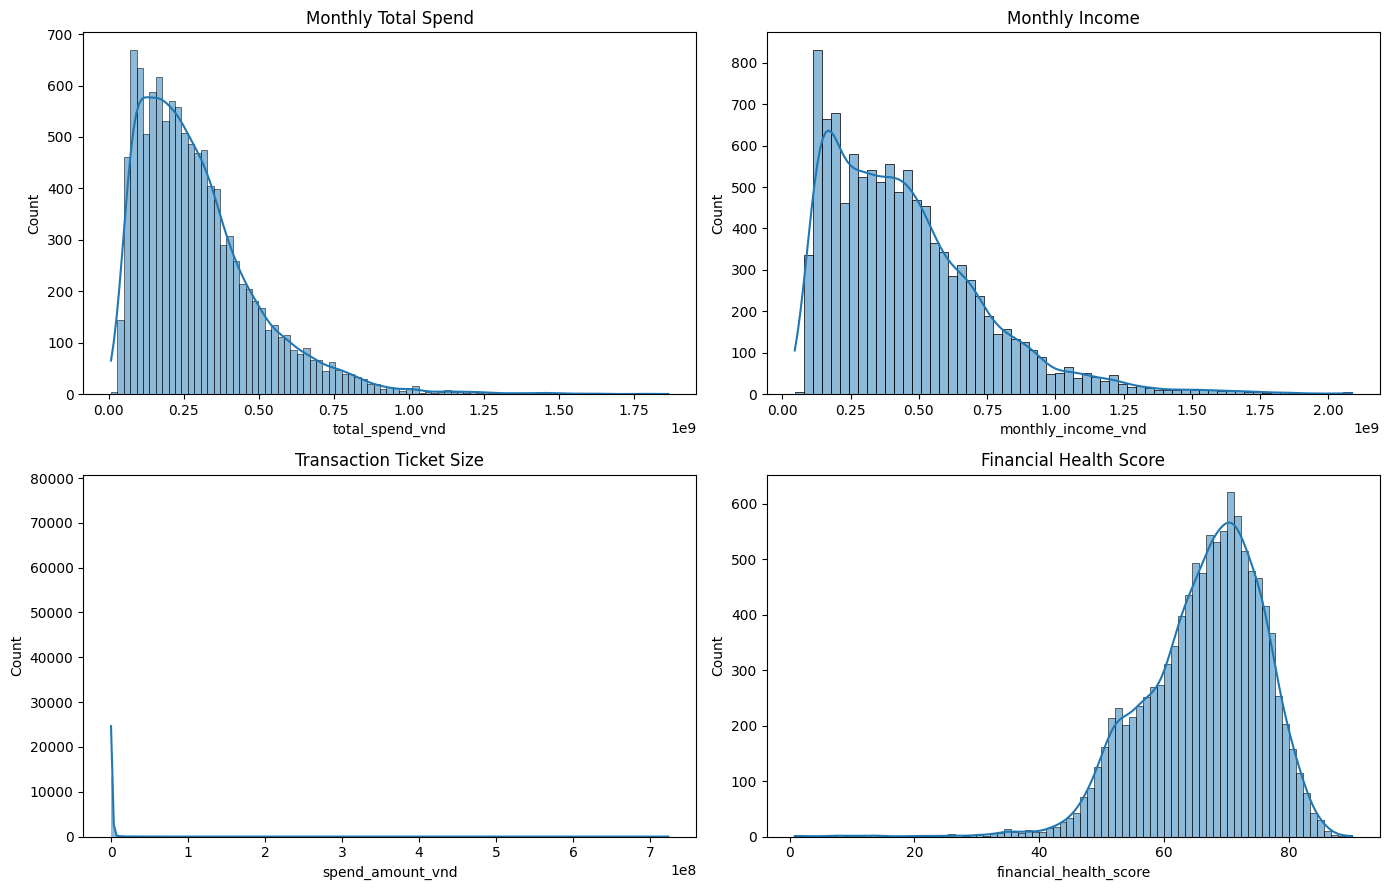

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(df_monthly['total_spend_vnd'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Monthly Total Spend')
sns.histplot(df_monthly['monthly_income_vnd'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Monthly Income')
sns.histplot(df_txn['spend_amount_vnd'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Transaction Ticket Size')
sns.histplot(df_monthly['financial_health_score'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Financial Health Score')
plt.tight_layout()
plt.show()

In [14]:
def iqr_outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'lower_bound': lower, 'upper_bound': upper,
        'outlier_count': ((series < lower) | (series > upper)).sum(),
        'outlier_pct': ((series < lower) | (series > upper)).mean() * 100
    })

for name, series in {
    'Monthly total spend': df_monthly['total_spend_vnd'],
    'Monthly income': df_monthly['monthly_income_vnd'],
    'Transaction ticket size': df_txn['spend_amount_vnd'],
    'Financial health score': df_monthly['financial_health_score']
}.items():
    print(f'\n{name}')
    display(iqr_outlier_summary(series))


Monthly total spend


Q1               1.470350e+08
Q3               3.859602e+08
IQR              2.389252e+08
lower_bound     -2.113529e+08
upper_bound      7.443481e+08
outlier_count    4.080000e+02
outlier_pct      3.711790e+00
dtype: float64


Monthly income


Q1               2.253550e+08
Q3               5.950350e+08
IQR              3.696800e+08
lower_bound     -3.291650e+08
upper_bound      1.149555e+09
outlier_count    3.070000e+02
outlier_pct      2.792940e+00
dtype: float64


Transaction ticket size


Q1               2.410000e+05
Q3               2.077000e+06
IQR              1.836000e+06
lower_bound     -2.513000e+06
upper_bound      4.831000e+06
outlier_count    9.510100e+04
outlier_pct      5.133951e+00
dtype: float64


Financial health score


Q1                60.70000
Q3                73.20000
IQR               12.50000
lower_bound       41.95000
upper_bound       91.95000
outlier_count    113.00000
outlier_pct        1.02802
dtype: float64

**Overall Comment:** The distribution and IQR-based outlier checks identify extreme observations across all four variables. Transaction ticket size has the highest outlier rate at 5.13%, followed by monthly total spend at 3.71% and monthly income at 2.79%. Financial health score has a smaller outlier rate of 1.03%. These observations should not be treated as data errors automatically, as extreme values may represent genuine consumer behavior. Therefore, the outliers should be retained for analysis but considered when interpreting averages, distributions, and subsequent business questions.

---
## 7. Task 1 Questions

## Q1. Seasonal Spending

**Question:** Which month records the highest total spend, and how much does it account for (in VND and as a % of annual spend) compared to the lowest spending month? Is this peak driven primarily by higher transaction count or larger ticket sizes? What does this pattern reveal about consumer spending behavior during peak periods?



In [15]:
# 1. Aggregate spending and transaction volume by month
q1 = (
    df_monthly
    .groupby('analysis_month')
    .agg(
        total_spend_vnd=('total_spend_vnd', 'sum'),
        transaction_count=('transaction_count', 'sum')
    )
    .reset_index()
)


# 2. Calculate average ticket size
# Total Spend = Transaction Count × Average Ticket
q1['avg_ticket_vnd'] = (
    q1['total_spend_vnd'] / q1['transaction_count']
)


# 3. Calculate each month's share of annual spending
annual_total_spend = q1['total_spend_vnd'].sum()

q1['annual_spend_share_pct'] = (
    q1['total_spend_vnd']
    / annual_total_spend
    * 100
)


# 4. Identify the highest- and lowest-spending months
peak = q1.loc[
    q1['total_spend_vnd'].idxmax()
]

low = q1.loc[
    q1['total_spend_vnd'].idxmin()
]


# ============================================================
# 5. Compare highest vs. lowest spending month
# ============================================================

# Difference in total spending
spend_difference_vnd = (
    peak['total_spend_vnd']
    - low['total_spend_vnd']
)

# Percentage difference relative to the lowest month
spend_difference_pct = (
    spend_difference_vnd
    / low['total_spend_vnd']
    * 100
)

# Spending ratio
spend_ratio = (
    peak['total_spend_vnd']
    / low['total_spend_vnd']
)


# ============================================================
# 6. Compare transaction volume
# ============================================================

transaction_difference = (
    peak['transaction_count']
    - low['transaction_count']
)

transaction_difference_pct = (
    transaction_difference
    / low['transaction_count']
    * 100
)


# ============================================================
# 7. Compare average ticket size
# ============================================================

ticket_difference_vnd = (
    peak['avg_ticket_vnd']
    - low['avg_ticket_vnd']
)

ticket_difference_pct = (
    ticket_difference_vnd
    / low['avg_ticket_vnd']
    * 100
)


# ============================================================
# 8. Display key results
# ============================================================

print("========== Q1. SEASONAL SPENDING ==========\n")

print("HIGHEST SPENDING MONTH")
print("--------------------------------------------")
print(
    f"Month: "
    f"{peak['analysis_month'].strftime('%Y-%m')}"
)
print(
    f"Total spend: "
    f"{peak['total_spend_vnd']:,.0f} VND"
)
print(
    f"Share of annual spend: "
    f"{peak['annual_spend_share_pct']:.2f}%"
)
print(
    f"Transaction count: "
    f"{peak['transaction_count']:,.0f}"
)
print(
    f"Average ticket: "
    f"{peak['avg_ticket_vnd']:,.0f} VND"
)


print("\nLOWEST SPENDING MONTH")
print("--------------------------------------------")
print(
    f"Month: "
    f"{low['analysis_month'].strftime('%Y-%m')}"
)
print(
    f"Total spend: "
    f"{low['total_spend_vnd']:,.0f} VND"
)
print(
    f"Share of annual spend: "
    f"{low['annual_spend_share_pct']:.2f}%"
)
print(
    f"Transaction count: "
    f"{low['transaction_count']:,.0f}"
)
print(
    f"Average ticket: "
    f"{low['avg_ticket_vnd']:,.0f} VND"
)


print("\nPEAK VS. LOWEST MONTH")
print("--------------------------------------------")
print(
    f"Spend difference: "
    f"{spend_difference_vnd:,.0f} VND"
)
print(
    f"Spend increase: "
    f"{spend_difference_pct:.2f}%"
)
print(
    f"Spend ratio: "
    f"{spend_ratio:.2f}x"
)

print(
    f"\nTransaction difference: "
    f"{transaction_difference:,.0f}"
)
print(
    f"Transaction increase: "
    f"{transaction_difference_pct:.2f}%"
)

print(
    f"\nAverage ticket difference: "
    f"{ticket_difference_vnd:,.0f} VND"
)
print(
    f"Average ticket change: "
    f"{ticket_difference_pct:.2f}%"
)


# ============================================================
# 9. Display monthly trend table
# ============================================================

display(
    q1[
        [
            'analysis_month',
            'total_spend_vnd',
            'annual_spend_share_pct',
            'transaction_count',
            'avg_ticket_vnd'
        ]
    ]
)

========== Q1. SEASONAL SPENDING ==========

HIGHEST SPENDING MONTH
--------------------------------------------
Month: 2025-12
Total spend: 488,032,709,000 VND
Share of annual spend: 15.04%
Transaction count: 280,598
Average ticket: 1,739,259 VND

LOWEST SPENDING MONTH
--------------------------------------------
Month: 2025-02
Total spend: 174,365,111,000 VND
Share of annual spend: 5.37%
Transaction count: 97,657
Average ticket: 1,785,485 VND

PEAK VS. LOWEST MONTH
--------------------------------------------
Spend difference: 313,667,598,000 VND
Spend increase: 179.89%
Spend ratio: 2.80x

Transaction difference: 182,941
Transaction increase: 187.33%

Average ticket difference: -46,226 VND
Average ticket change: -2.59%


,analysis_month,total_spend_vnd,annual_spend_share_pct,transaction_count,avg_ticket_vnd
0,2025-01-01,185570433000,5.719304,104727,1.771945e+06
1,2025-02-01,174365111000,5.373955,97657,1.785485e+06
2,2025-03-01,254750003000,7.851427,143789,1.771693e+06
3,2025-04-01,236320934000,7.283441,134970,1.750915e+06
4,2025-05-01,257623444000,7.939987,146875,1.754032e+06
5,2025-06-01,305572891000,9.417795,173869,1.757489e+06
6,2025-07-01,299556013000,9.232354,172444,1.737121e+06
7,2025-08-01,304519084000,9.385317,176118,1.729063e+06
8,2025-09-01,246520864000,7.597804,140185,1.758540e+06
9,2025-10-01,243005639000,7.489465,138106,1.759559e+06


### Q1. Seasonal Spending — Interpretation

- **Highest-spending month:** December 2025, with total spending of 488.03 billion VND, representing 15.04% of annual spending.
- **Lowest-spending month:** February 2025, with total spending of 174.37 billion VND, representing 5.37% of annual spending.
- December spending was 313.67 billion VND higher than February, equivalent to approximately 180% higher spending or 2.80 times the February level.

#### What drives the spending peak?

The December peak is primarily **volume-driven rather than ticket-size-driven**.

- Transaction count increased from 97,657 in February to 280,598 in December, an increase of approximately 187%.
- Average ticket size decreased slightly from 1.79 million VND to 1.74 million VND, a decrease of approximately 2.6%.

Therefore, the substantially higher spending in December is mainly explained by a sharp increase in transaction frequency, rather than consumers spending substantially more per transaction.

#### Consumer spending behavior

This pattern suggests a strong **seasonal effect** in consumer spending. During the peak period, consumers tend to make purchases more frequently, while the average value of individual transactions remains relatively stable.

Overall, the December spending peak reflects **higher purchase frequency rather than larger ticket sizes**.

## Q2. Essential vs. Discretionary Spend by Financial Health

**Question:** Compare the proportion of Essential vs. Discretionary spend between financially stressed customers (financial_health_score < 40) and healthy customers (financial_health_score 80). Based on the data, what does this spending composition reveal about how financial stress alters a customer's budget allocation?

,Stressed <40,Healthy >=80
rows,9.500000e+01,4.750000e+02
row_share_pct,8.600000e-01,4.320000e+00
customers,7.000000e+01,3.030000e+02
customer_share_pct,7.010000e+00,3.033000e+01
total_spend_vnd,3.377737e+10,5.579163e+10
essential_spend_vnd,9.579242e+09,3.317377e+10
discretionary_spend_vnd,2.419813e+10,2.261786e+10
essential_share_pct,2.836000e+01,5.946000e+01
discretionary_share_pct,7.164000e+01,4.054000e+01
avg_essential_ratio_pct,2.883000e+01,6.110000e+01


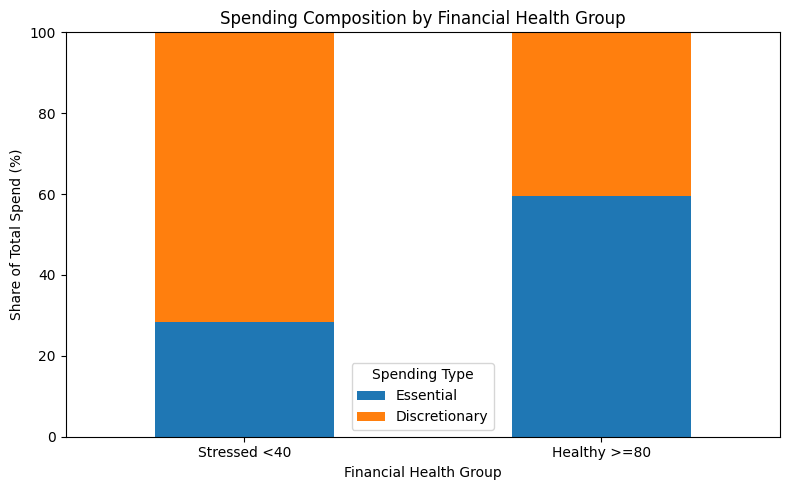

In [16]:
stressed = df_monthly[
    df_monthly['financial_health_score'] < 40
].copy()

healthy_80 = df_monthly[
    df_monthly['financial_health_score'] >= 80
].copy()


def q2_summary(df, total_rows, total_customers):
    total_spend = df['total_spend_vnd'].sum()
    essential_spend = df['essential_spend_vnd'].sum()
    discretionary_spend = df['discretionary_spend_vnd'].sum()

    return pd.Series({
        'rows': len(df),
        'row_share_pct': len(df) / total_rows * 100,
        'customers': df['consumer_id'].nunique(),
        'customer_share_pct': (
            df['consumer_id'].nunique() / total_customers * 100
        ),

        'total_spend_vnd': total_spend,
        'essential_spend_vnd': essential_spend,
        'discretionary_spend_vnd': discretionary_spend,

        'essential_share_pct': (
            essential_spend / total_spend * 100
        ),
        'discretionary_share_pct': (
            discretionary_spend / total_spend * 100
        ),

        'avg_essential_ratio_pct': (
            df['essential_spend_ratio'].mean() * 100
        ),
        'avg_discretionary_ratio_pct': (
            df['discretionary_spend_ratio'].mean() * 100
        ),

        'avg_spend_to_income_ratio_pct': (
            df['spend_to_income_ratio'].mean() * 100
        ),

        'avg_financial_health_score': (
            df['financial_health_score'].mean()
        )
    })


# Group summary
total_rows = len(df_monthly)
total_customers = df_monthly['consumer_id'].nunique()

q2_result = pd.DataFrame({
    'Stressed <40': q2_summary(
        stressed, total_rows, total_customers
    ),
    'Healthy >=80': q2_summary(
        healthy_80, total_rows, total_customers
    )
})

display(q2_result.round(2))


# Budget allocation gaps
essential_gap = (
    q2_result.loc['essential_share_pct', 'Stressed <40']
    - q2_result.loc['essential_share_pct', 'Healthy >=80']
)

discretionary_gap = (
    q2_result.loc['discretionary_share_pct', 'Stressed <40']
    - q2_result.loc['discretionary_share_pct', 'Healthy >=80']
)

spend_income_gap = (
    q2_result.loc['avg_spend_to_income_ratio_pct', 'Stressed <40']
    - q2_result.loc['avg_spend_to_income_ratio_pct', 'Healthy >=80']
)


# Budget composition
budget_share = pd.DataFrame({
    'Essential': [
        q2_result.loc[
            'essential_share_pct', 'Stressed <40'
        ],
        q2_result.loc[
            'essential_share_pct', 'Healthy >=80'
        ]
    ],
    'Discretionary': [
        q2_result.loc[
            'discretionary_share_pct', 'Stressed <40'
        ],
        q2_result.loc[
            'discretionary_share_pct', 'Healthy >=80'
        ]
    ]
}, index=['Stressed <40', 'Healthy >=80'])


# Visualization
ax = budget_share.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

ax.set_title('Spending Composition by Financial Health Group')
ax.set_ylabel('Share of Total Spend (%)')
ax.set_xlabel('Financial Health Group')
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title='Spending Type')
plt.tight_layout()
plt.show()

### **Q2. Essential vs. Discretionary Spending — Interpretation**

- **Financially stressed customers (<40):** 95 consumer-month observations from 70 unique customers, with total spending of **33.78 billion VND**. Essential spending accounts for **28.36%**, while Discretionary spending accounts for **71.64%**.

- **Healthy customers (≥80):** 475 consumer-month observations from 303 unique customers, with total spending of **55.79 billion VND**. Essential spending accounts for **59.46%**, while Discretionary spending accounts for **40.54%**.

#### **Budget Allocation**

- The stressed group allocates **31.10 percentage points less** to Essential spending than the healthy group (28.36% vs. 59.46%).
- Conversely, the stressed group allocates **31.10 percentage points more** to Discretionary spending (71.64% vs. 40.54%).

This indicates that the stressed group has a substantially more **Discretionary-heavy spending structure**, while the healthy group allocates a larger proportion of spending to Essential needs.

#### **Financial Pressure**

- **Stressed <40:** Spend-to-income ratio = **209.80%**
- **Healthy ≥80:** Spend-to-income ratio = **28.86%**

The stressed group's ratio is approximately **7.27× higher**, indicating substantially greater spending relative to the reported income measure.

#### **Overall**

Within this synthetic dataset, financially stressed customers show both **higher spending pressure relative to income** and a **higher share of Discretionary spending**. In contrast, healthy customers allocate a larger proportion of their spending to Essential categories.

These findings are descriptive and should not be interpreted as evidence that financial stress directly causes higher discretionary spending.

## Q3. Regional Digital Adoption Gap

**Question:** Identify 2 or more provinces/cities that generate high total spend volume but have a lower-than-average digital transaction share. Compare their channel breakdown (POS vs. digital channels) to quantify and explain the nature of their digital adoption gap.

In [17]:
digital_channels = ['E-commerce', 'QR Payment']

# Define digital transactions
df_txn['digital_flag_derived'] = (
    df_txn['transaction_channel']
    .isin(digital_channels)
    .astype(int)
)

# 1. Overall average digital transaction share
overall_digital_share = df_txn['digital_flag_derived'].mean() * 100

# 2. Calculate total spend and transaction metrics by province/city
q3 = df_txn.groupby('province_city').agg(
    total_spend_vnd=('spend_amount_vnd', 'sum'),
    transaction_count=('transaction_id', 'count'),
    digital_transactions=('digital_flag_derived', 'sum')
).reset_index()

# 3. Digital transaction share by province/city
q3['digital_transaction_share_pct'] = (
    q3['digital_transactions'] / q3['transaction_count'] * 100
)

# 4. Average provincial total spend
avg_provincial_spend = q3['total_spend_vnd'].mean()

# 5. Filter provinces with above-average total spend
q3_gap = q3[
    q3['total_spend_vnd'] > avg_provincial_spend
].copy()

# 6. Calculate digital adoption gap vs overall average
q3_gap['digital_adoption_gap_pct'] = (
    q3_gap['digital_transaction_share_pct'] - overall_digital_share
)

# Keep provinces below overall digital average
q3_gap = q3_gap[
    q3_gap['digital_transaction_share_pct'] < overall_digital_share
].copy()

# Sort by total spend
q3_gap = q3_gap.sort_values(
    'total_spend_vnd',
    ascending=False
)

print(f'Overall digital transaction share: {overall_digital_share:.2f}%')
print(f'Average provincial total spend: {avg_provincial_spend:,.0f} VND')

display(q3_gap)

Overall digital transaction share: 28.58%
Average provincial total spend: 95,430,381,118 VND


,province_city,total_spend_vnd,transaction_count,digital_transactions,digital_transaction_share_pct,digital_adoption_gap_pct
7,Hà Nội,267264508000,149952,42581,28.396420,-0.180222
32,Đồng Nai,183072471000,106057,30094,28.375308,-0.201334
14,Lâm Đồng,135389980000,75439,21409,28.379220,-0.197422
9,Hưng Yên,116442487000,66638,18817,28.237642,-0.339000
28,Vĩnh Long,106026604000,55632,15678,28.181622,-0.395020


In [18]:
# Channel breakdown for selected provinces

channel_breakdown = (
    df_txn[
        df_txn['province_city'].isin(q3_gap['province_city'])
    ]
    .groupby(['province_city', 'transaction_channel'])
    .agg(
        transaction_count=('transaction_id', 'count'),
        total_spend_vnd=('spend_amount_vnd', 'sum')
    )
    .reset_index()
)

# Calculate transaction share within each province
channel_breakdown['transaction_share_pct'] = (
    channel_breakdown['transaction_count']
    / channel_breakdown.groupby('province_city')['transaction_count'].transform('sum')
    * 100
)

# Pivot for easier comparison
channel_table = channel_breakdown.pivot(
    index='province_city',
    columns='transaction_channel',
    values='transaction_share_pct'
).fillna(0)

display(
    channel_breakdown
    .sort_values(['province_city', 'transaction_share_pct'], ascending=[True, False])
    .round(2)
)

,province_city,transaction_channel,transaction_count,total_spend_vnd,transaction_share_pct
2,Hà Nội,POS,88658,157925880000,59.12
3,Hà Nội,QR Payment,29802,53057845000,19.87
0,Hà Nội,E-commerce,12779,24663563000,8.52
1,Hà Nội,Mobile App,11397,19788366000,7.60
4,Hà Nội,Recurring Payment,7316,11828854000,4.88
7,Hưng Yên,POS,39460,68309349000,59.22
8,Hưng Yên,QR Payment,13205,23695130000,19.82
5,Hưng Yên,E-commerce,5612,10814181000,8.42
6,Hưng Yên,Mobile App,4944,8162341000,7.42
9,Hưng Yên,Recurring Payment,3417,5461486000,5.13


### **Q3. Regional Digital Adoption — Interpretation**

The overall digital transaction share is **28.58%**, while the average provincial total spending is **95.43 billion VND**.

Five provinces/cities have above-average total spending but slightly below-average digital transaction adoption: **Hà Nội, Đồng Nai, Lâm Đồng, Hưng Yên, and Vĩnh Long**.

#### **Nature of the Digital Adoption Gap**

The digital adoption gap is relatively small, ranging from **0.18 to 0.40 percentage points** below the overall average.

The channel breakdown shows that the main difference comes from the continued dominance of **POS transactions**, which account for around **58.65%–59.27%** of transactions across these provinces.

Meanwhile, **QR Payment** accounts for approximately **19.35%–19.87%**, while **E-commerce** contributes around **8.42%–8.83%**. Mobile App and Recurring Payment make up the remaining share.

Therefore, the digital adoption gap is mainly characterized by a **high reliance on POS transactions**, rather than a substantial absence of digital channels. Digital channels are already present at a similar level across these high-spending provinces, but POS remains the dominant transaction channel.

## Q4. Merchant Category: Transaction Count vs. Spend Volume

**Question:** Identify the top category by transaction count and the top category by total spend volume. Compare their average ticket sizes (VND per transaction) and explain how consumer usage behavior differs between these two categories.

In [22]:
q4 = df_txn.groupby('spending_category').agg(
    transaction_count=('transaction_id', 'count'),
    total_spend_vnd=('spend_amount_vnd', 'sum')
).reset_index()

# Average ticket size
q4['avg_ticket_vnd'] = (
    q4['total_spend_vnd'] / q4['transaction_count']
)

# Identify top categories
top_volume = q4.loc[
    q4['transaction_count'].idxmax()
]

top_spend = q4.loc[
    q4['total_spend_vnd'].idxmax()
]

# Compare the two categories
q4_compare = q4[
    q4['spending_category'].isin([
        top_volume['spending_category'],
        top_spend['spending_category']
    ])
].copy()

q4_compare['transaction_share_pct'] = (
    q4_compare['transaction_count']
    / q4['transaction_count'].sum()
    * 100
)

q4_compare['spend_share_pct'] = (
    q4_compare['total_spend_vnd']
    / q4['total_spend_vnd'].sum()
    * 100
)

q4_compare = q4_compare.sort_values(
    'total_spend_vnd',
    ascending=False
)

print(
    'Top category by transaction volume:',
    top_volume['spending_category']
)

print(
    'Top category by total spend:',
    top_spend['spending_category']
)

print(
    'Average ticket - top volume category:',
    f"{top_volume['avg_ticket_vnd']:,.0f} VND"
)

print(
    'Average ticket - top spend category:',
    f"{top_spend['avg_ticket_vnd']:,.0f} VND"
)

display(q4_compare.round(2))

Top category by transaction volume: Xăng dầu và di chuyển
Top category by total spend: Siêu thị và tạp hóa tại cửa hàng
Average ticket - top volume category: 1,586,933 VND
Average ticket - top spend category: 2,916,003 VND


,spending_category,transaction_count,total_spend_vnd,avg_ticket_vnd,transaction_share_pct,spend_share_pct
8,Siêu thị và tạp hóa tại cửa hàng,176191,513773547000,2916003.35,9.51,15.83
12,Xăng dầu và di chuyển,188029,298389366000,1586932.69,10.15,9.20


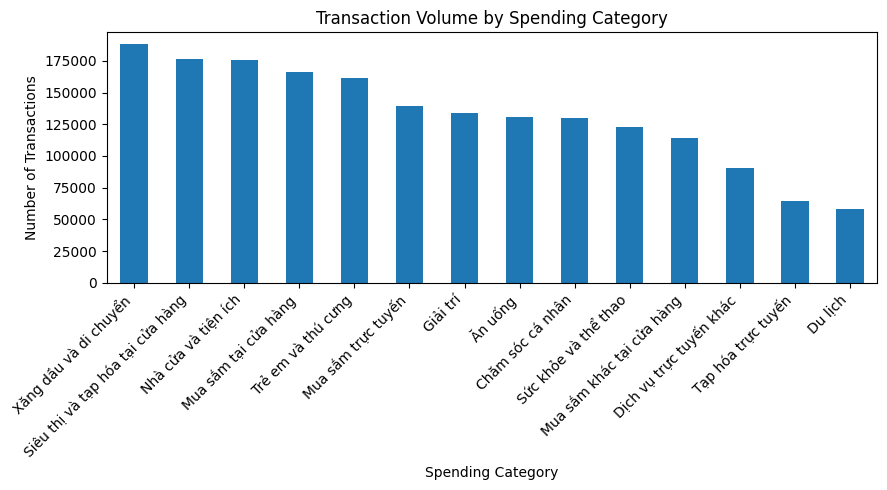

In [23]:
# Transaction volume by category

volume_chart = q4.sort_values(
    'transaction_count',
    ascending=False
)

ax = volume_chart.plot(
    x='spending_category',
    y='transaction_count',
    kind='bar',
    figsize=(9, 5),
    legend=False
)

ax.set_title('Transaction Volume by Spending Category')
ax.set_xlabel('Spending Category')
ax.set_ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Q4. Spending Category — Interpretation**

The category with the highest **transaction volume** is **Xăng dầu và di chuyển**, with **188,029 transactions**. However, **Siêu thị và tạp hóa tại cửa hàng** has the highest **total spending**, reaching **513.77 billion VND**.

#### **Average Ticket Comparison**

- **Siêu thị và tạp hóa tại cửa hàng:** 2.92 million VND per transaction.
- **Xăng dầu và di chuyển:** 1.59 million VND per transaction.

The average ticket for **Siêu thị và tạp hóa tại cửa hàng** is approximately **1.84× higher** than **Xăng dầu và di chuyển**.

Although **Xăng dầu và di chuyển** has a higher transaction volume (10.15% vs. 9.51%), its lower average ticket results in a smaller share of total spending (9.20% vs. 15.83%).

#### **Consumer Usage Behavior**

This indicates different spending patterns between the two categories. **Xăng dầu và di chuyển** represents more frequent but lower-value transactions, consistent with routine and recurring purchases. In contrast, **Siêu thị và tạp hóa tại cửa hàng** has fewer transactions but a substantially higher average ticket, resulting in a much larger contribution to total spending.

#### **Overall**

The comparison shows that **transaction frequency alone does not determine total spending**. A category with fewer transactions can generate significantly higher total spend when its average ticket size is larger.

## Q5. Age Cohort and Financial Vulnerability

**Question:** Which age cohort maintains active transaction frequency while recording the lowest average financial_health_score? Contrast their spending metrics (essential spend ratio and spend-to-income ratio) with other age cohorts to explain the drivers of their financial vulnerability.

In [27]:
age_bins = [0, 24, 34, 44, 54, 64, 200]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

df_monthly['age_cohort'] = pd.cut(
    df_monthly['age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

q5 = df_monthly.groupby(
    'age_cohort',
    observed=False
).agg(
    customers=('consumer_id', 'nunique'),
    avg_transaction_count=('transaction_count', 'mean'),
    avg_active_transaction_days=('active_transaction_days', 'mean'),
    avg_financial_health_score=('financial_health_score', 'mean'),
    avg_essential_spend_ratio=('essential_spend_ratio', 'mean'),
    avg_spend_to_income_ratio=('spend_to_income_ratio', 'mean'),
    avg_total_spend_vnd=('total_spend_vnd', 'mean')
).reset_index()

display(q5.round(2))


# Define active transaction frequency benchmark

avg_active_days = q5['avg_active_transaction_days'].mean()

active_cohorts = q5[
    q5['avg_active_transaction_days'] >= avg_active_days
].copy()

# Among active cohorts, identify the one with the lowest financial health

target_cohort = active_cohorts.loc[
    active_cohorts['avg_financial_health_score'].idxmin()
]

print(
    'Average active transaction days benchmark:',
    f"{avg_active_days:.2f}"
)

print(
    'Selected age cohort:',
    target_cohort['age_cohort']
)

print(
    'Average active transaction days:',
    f"{target_cohort['avg_active_transaction_days']:.2f}"
)

print(
    'Average financial health score:',
    f"{target_cohort['avg_financial_health_score']:.2f}"
)

print(
    'Average essential spend ratio:',
    f"{target_cohort['avg_essential_spend_ratio']*100:.2f}%"
)

print(
    'Average spend-to-income ratio:',
    f"{target_cohort['avg_spend_to_income_ratio']*100:.2f}%"
)

# Compare the selected cohort with other age cohorts

q5_compare = q5[
    [
        'age_cohort',
        'avg_active_transaction_days',
        'avg_financial_health_score',
        'avg_essential_spend_ratio',
        'avg_spend_to_income_ratio'
    ]
].copy()

q5_compare['avg_essential_spend_ratio_pct'] = (
    q5_compare['avg_essential_spend_ratio'] * 100
)

q5_compare['avg_spend_to_income_ratio_pct'] = (
    q5_compare['avg_spend_to_income_ratio'] * 100
)

display(
    q5_compare[
        [
            'age_cohort',
            'avg_active_transaction_days',
            'avg_financial_health_score',
            'avg_essential_spend_ratio_pct',
            'avg_spend_to_income_ratio_pct'
        ]
    ].round(2)
)

,age_cohort,customers,avg_transaction_count,avg_active_transaction_days,avg_financial_health_score,avg_essential_spend_ratio,avg_spend_to_income_ratio,avg_total_spend_vnd
0,<25,69,221.61,28.44,65.94,0.35,0.68,3.412562e+08
1,25-34,177,178.75,28.94,65.79,0.47,0.72,3.274927e+08
2,35-44,165,199.36,29.28,66.44,0.46,0.69,3.753180e+08
3,45-54,198,176.86,28.85,65.98,0.49,0.71,3.103167e+08
4,55-64,175,129.57,27.94,67.00,0.51,0.70,2.147421e+08
5,65+,215,139.15,28.16,66.86,0.51,0.69,2.292998e+08


Average active transaction days benchmark: 28.60
Selected age cohort: 25-34
Average active transaction days: 28.94
Average financial health score: 65.79
Average essential spend ratio: 46.75%
Average spend-to-income ratio: 71.58%


,age_cohort,avg_active_transaction_days,avg_financial_health_score,avg_essential_spend_ratio_pct,avg_spend_to_income_ratio_pct
0,<25,28.44,65.94,35.49,67.60
1,25-34,28.94,65.79,46.75,71.58
2,35-44,29.28,66.44,46.41,69.42
3,45-54,28.85,65.98,49.33,71.23
4,55-64,27.94,67.00,50.81,69.60
5,65+,28.16,66.86,50.92,68.53


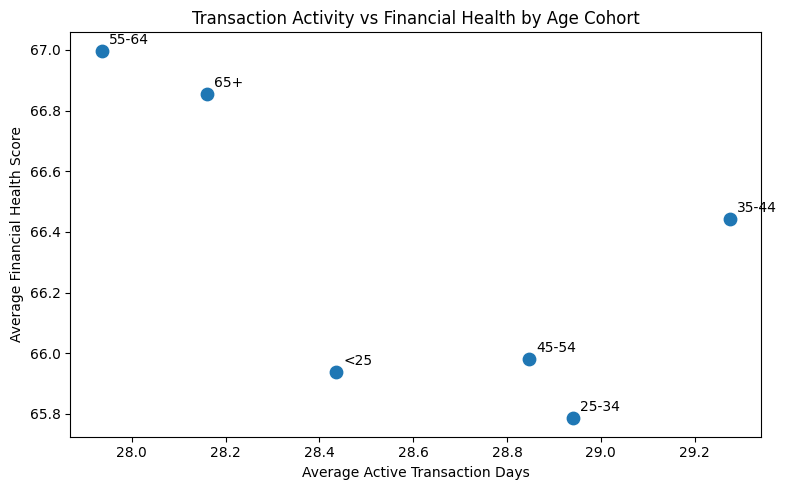

In [28]:
# Activity vs Financial Health

ax = q5.plot(
    x='avg_active_transaction_days',
    y='avg_financial_health_score',
    kind='scatter',
    figsize=(8, 5),
    s=80
)

for _, row in q5.iterrows():
    ax.annotate(
        row['age_cohort'],
        (
            row['avg_active_transaction_days'],
            row['avg_financial_health_score']
        ),
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.set_title('Transaction Activity vs Financial Health by Age Cohort')
ax.set_xlabel('Average Active Transaction Days')
ax.set_ylabel('Average Financial Health Score')

plt.tight_layout()
plt.show()

### **Q5. Age Cohort — Interpretation**

The **25–34** age cohort maintains relatively active transaction behavior, with **28.94 active transaction days**, slightly above the overall cohort benchmark of **28.60 days**. Among the relatively active cohorts, it records the **lowest average financial health score at 65.79**.

#### **Spending Metrics**

The 25–34 cohort has an **essential spend ratio of 46.75%**, which is not the highest among age cohorts. However, it records the **highest spend-to-income ratio at 71.58%**, slightly above the other cohorts.

This suggests that the financial vulnerability of the 25–34 cohort is more closely associated with **higher spending pressure relative to income** rather than an unusually high allocation to essential spending.

#### **Overall**

The 25–34 cohort combines **relatively active transaction behavior, the lowest financial health among active cohorts, and the highest spend-to-income ratio**. However, the differences in financial health and spending pressure across cohorts are relatively small, so these results should be interpreted as descriptive patterns rather than strong evidence of a distinct age-related vulnerability.